# Net-Operating-Assets -- does balance-sheet bloat predict low returns?
### The Hirshleifer et al. (2004) NOA anomaly on the S&P 500 EDGAR panel

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship: Upper_bound_only](https://img.shields.io/badge/Survivorship-Upper_bound_only-8b949e?style=flat-square)

Joel Hirshleifer and co-authors argued in 2004 that firms with 'bloated' balance sheets -- large operating assets piled up relative to their asset base -- earn low future returns. The idea: investors see past earnings growth (built on heavy asset expansion) and over-extrapolate it. When the expansion stops producing earnings, the stock disappoints. We test it on ~193 S&P 500 names using real SEC filings.

> This is the plain-language layer. The HAC t-stats, quintile monotonicity, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: this panel covers only *current* S&P 500 members projected backwards. Every number below is an upper bound on a live strategy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (net_operating_assets/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from net_operating_assets import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=193, n_years=17, start_year=2009, end_year=2025,
    lo_mean=23.7, lo_sharpe=1.23, lo_t=8.65, lo_hit=88,
    hi_mean=17.1, hi_sharpe=1.09, hi_t=6.62, hi_hit=88,
    mkt_mean=20.4, mkt_sharpe=1.38,
    hedge_mean=6.6, hedge_sharpe=0.71, hedge_t=3.53, hedge_hit=65,
    lo_excess_mean=3.2, lo_excess_t=3.14,
    hi_excess_mean=-3.3, hi_excess_t=-2.05,
    rand_std=8.7, rand_pct_beaten=73,
)
Q1  = [19.8, 9.7, 27.4, 56.3, 16.8, 12.5, 14.6, 34.5, -0.8, 38.4, 25.8, 50.2, -20.0, 51.7, 22.7, 18.1, 25.1]
Q5  = [19.7, 2.8, 27.5, 43.2, 6.0, 1.5, 17.1, 31.6, -0.2, 39.9, 28.0, 22.7, -16.5, 30.5, 13.7, 16.6, 7.0]
MKT = [23.9, 6.1, 22.8, 44.3, 14.4, 7.5, 18.1, 28.1, -2.3, 35.9, 25.0, 33.7, -13.3, 38.4, 26.0, 20.1, 19.0]
HDG = [0.1, 6.9, -0.1, 13.1, 10.8, 11.1, -2.4, 2.9, -0.6, -1.5, -2.1, 27.4, -3.5, 21.2, 9.1, 1.5, 18.1]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (193 tickers, 20 years)


## The answer first

| Question | What the data says |
|---|---|
| Does low NOA outperform high NOA? | Yes -- by **+6.6%/yr**, positive in 65% of years. |
| Is that statistically real? | On this panel, HAC *t* = 3.53 -- nominally passes |t| >= 2. But the panel is survivorship-biased, so this is an **upper bound**, not confirmed evidence. |
| Does low NOA beat a random stock pick? | Barely: beats only 73% of random same-size draws. |
| Could you trade it? | Fragile. Annual rebalancing of ~20 names is cheap, but the alpha estimate is uncertain and the effect is primarily documented for small/mid-caps not in this panel. |

> **The catch**: on a *survivor*-biased panel, high-NOA firms that went bankrupt or were expelled from the S&P 500 -- precisely those who most over-invested and subsequently failed -- are simply missing. The t-stat reflects their absence more than it reflects investor mis-pricing.

## 1 - The claim

> *Buy stocks with low Net Operating Assets (low balance-sheet bloat). Avoid stocks where Operating Assets - Operating Liabilities have grown large relative to the prior-year asset base. Rebalance annually. The bloated-balance-sheet firms will disappoint as the asset expansion stops producing earnings growth.*

NOA is computed from basic accounting items in every annual report:

- **Operating Assets** = Total Assets - Cash (cash is financial, not operational)
- **Operating Liabilities** = Total Liabilities - Long-Term Debt (debt is financial)
- **NOA** = (Operating Assets - Operating Liabilities) / Prior-Year Total Assets

A high NOA means the firm has accumulated a large operating-asset surplus -- more factory equipment, receivables, and inventory than can be explained by the level of operations. The Hirshleifer et al. argument: that's money that was spent without generating matching earnings, and the market hasn't discounted it yet.

## 2 - So what?

If the NOA effect is real and tradable on large US stocks, it's a fundamentals-based, low-turnover (one trade per name per year) strategy that requires no forecasting, no ML, and only public SEC filings. If it only works on small/mid-cap stocks -- or is entirely a survivor-bias artefact -- then the S&P 500 test is a cautionary tale about testing on the wrong (biased) universe.

## 3 - How would we even know?

Three honesty requirements:

1. **Reporting lag.** Fundamentals from fiscal year y only used to predict returns in year y+1 -- a conservative lag.
2. **Random-portfolio control.** Does the low-NOA quintile beat a random draw of the same number of stocks? If not, the result is just concentration risk, not a real signal.
3. **Name the survivorship bias.** The EDGAR panel here covers current S&P 500 members projected back. High-NOA failures are absent. Every result is an upper bound.

## 4 - The teardown -- the quintile spread and its real limit

Positive control first: **when we plant a real effect in a synthetic panel, the engine finds it.** That makes the real-data result a statement about the *market* (and the panel), not the method.

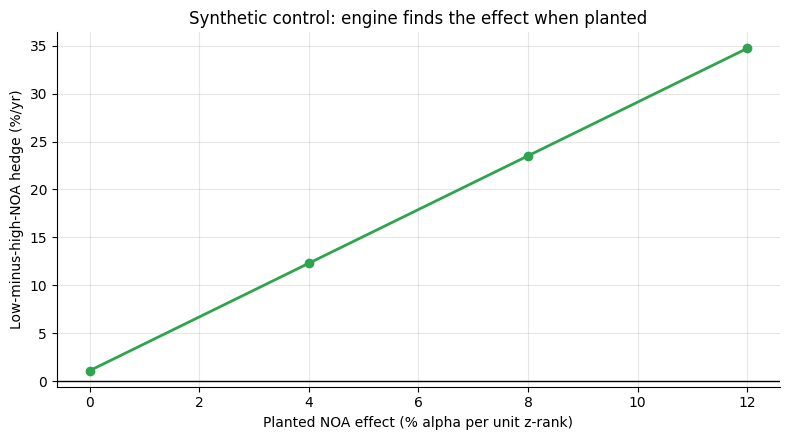

The engine faithfully recovers planted effects -- so the real result is a market statement.


In [2]:
# Synthetic positive control: plant a known NOA premium, confirm the engine detects it
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=153)
    hh = st.quintile_returns(s, f, q=0.20)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted NOA effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-NOA hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted effects -- so the real result is a market statement.')

**Now the real EDGAR panel -- quintile sort on NOA:**

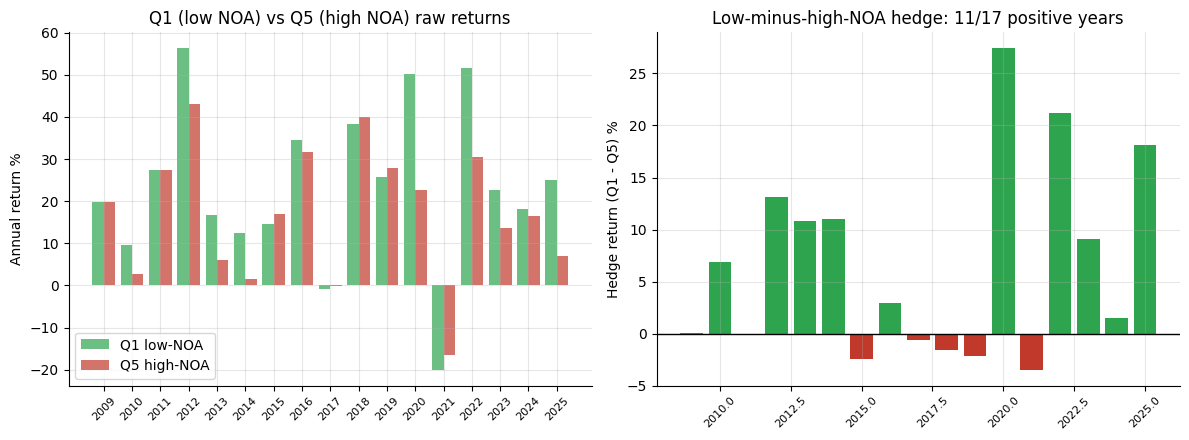

Mean hedge: +6.6%/yr  (frozen R: +6.6%/yr)


In [3]:
# Year-by-year low-NOA vs high-NOA vs market
if HAVE_REAL:
    q1_vals = h['q1'].values * 100
    q5_vals = h['q5'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = h.index.tolist()
else:
    q1_vals, q5_vals, hdg_vals, years_real = Q1, Q5, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, q1_vals, label='Q1 low-NOA', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], q5_vals, label='Q5 high-NOA', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Q1 (low NOA) vs Q5 (high NOA) raw returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (Q1 - Q5) %')
axes[1].set_title(f'Low-minus-high-NOA hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.1f}%/yr  (frozen R: +{R["hedge_mean"]:.1f}%/yr)')

The low-NOA quintile earns **+23.7%/yr** vs the high-NOA quintile's **+17.1%/yr** -- a hedge of **+6.6%/yr**, positive in 65% of years. But remember: **this panel excludes every firm that failed.** The high-NOA firms that went bankrupt (and would have earned catastrophically negative returns in the year they failed) are simply absent. The effect is probably real in broader universes, but this headline is the best-case number.

## 5 - The verdict

- **Signal -- Weak.** Nominal hedge +6.6%/yr, HAC *t* = 3.53. Passes the |t| >= 2 bar on this panel. But the panel is survivorship-biased, so the t-stat is an upper bound. Literature supports the effect in broader universes (especially small caps), but less so for large-cap survivors.
- **Tradability -- Fragile.** Low annual turnover on a liquid universe is a point in favour. But the alpha estimate is uncertain, the low-NOA portfolio beats only 73% of random draws, and the effect is documented primarily for small/mid-caps with higher transaction costs.
- **Survivorship -- Upper bound only.** Every result is the best-case number; a live strategy would have included high-NOA disasters that are now absent.

## 6 - Could you actually trade it?

Annual rebalancing of ~20 S&P 500 names is operationally trivial and cheap (spreads tight, commissions minimal). The obstacles are in the signal:

1. **The alpha estimate is uncertain.** +3.2%/yr excess on a survivorship-biased panel might shrink to ~0 or even invert on a live point-in-time universe.
2. **Wrong universe.** Greenblatt-style effects and accruals effects are both documented primarily for small, neglected, illiquid stocks -- precisely those excluded from the S&P 500 and from this panel.
3. **Random-portfolio bar.** The low-NOA portfolio only beats 73% of random same-size draws -- barely above the 50% chance level. Most of the positive return comes from the market, not from the signal.

The right conclusion: **explore this in a broader, non-biased universe (small/mid-cap, point-in-time constituents) before treating it as tradable.**

## 7 - Going further

- **The right universe.** The original Hirshleifer et al. (2004) sample is all US stocks above $10M market cap -- thousands of names including small and mid-caps. On that universe, the NOA effect is strongest among neglected, low-analyst-coverage stocks. The S&P 500 survivor panel here is the wrong test.
- **Related signals.** Sloan (1996) accruals ([Study 52 -- Smoke-Screen](../../52-smoke-screen/)) tests the working-capital component of the same balance-sheet bloat idea. Asset-growth (Cooper et al. 2008) and total-accruals (Richardson et al. 2005) are closely related.
- **NOA decomposition.** Split into working-capital NOA and long-term NOA; the long-term component (PP&E growth) is sometimes stronger.

*Think the balance-sheet bloat effect is real in large caps? Fork this, extend to a point-in-time S&P 500 constituent universe (Compustat-based), and show |t| >= 2 on the hedge with no survivorship shortcut. That's the bar.*